# Road2Work Answer Quality Model — v2.1
Notebook ini memakai dataset DS yang sudah dipisah: `dataset_train.csv`, `dataset_val.csv`, `dataset_test.csv`.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ds_assets import answer_quality_train_path, answer_quality_val_path, answer_quality_test_path
from model_builder import train_answer_quality_model, evaluate_split_datasets, predict_answer_quality

train_path = answer_quality_train_path()
val_path = answer_quality_val_path()
test_path = answer_quality_test_path()
print("Train:", train_path)
print("Val  :", val_path)
print("Test :", test_path)

d:\Virtual Environment\machine_learning\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


[ds_assets] ✅ Loaded role_skill_matrix: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\role_skill_matrix.json
[model_builder] ✅ Role matrix DS aktif (16 role).
Train: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_train.csv
Val  : D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_val.csv
Test : D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_test.csv


In [2]:
import pandas as pd

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n", name.upper(), df.shape)
    print(df["quality_label"].value_counts())


 TRAIN (2145, 26)
quality_label
Weak       715
Average    715
Strong     715
Name: count, dtype: int64

 VAL (460, 26)
quality_label
Strong     154
Average    153
Weak       153
Name: count, dtype: int64

 TEST (460, 26)
quality_label
Average    154
Strong     153
Weak       153
Name: count, dtype: int64


## Train model
Model menggunakan Functional API dengan dua output: `answer_quality` untuk accuracy dan `readiness_score` untuk MAE.

In [3]:
model = train_answer_quality_model(
    train_csv_path=str(train_path),
    val_csv_path=str(val_path),
    test_csv_path=str(test_path),
    epochs=25,
    min_accuracy=0.85,
    max_mae=0.02,
)


Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 215ms/step - answer_quality_accuracy: 0.8769 - answer_quality_loss: 0.5351 - loss: 0.5431 - readiness_score_loss: 4.7119e-04 - readiness_score_mae: 4.7800e-04 - val_answer_quality_accuracy: 0.9978 - val_answer_quality_loss: 0.0474 - val_loss: 0.0480 - val_readiness_score_loss: 0.0016 - val_readiness_score_mae: 0.0016
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - answer_quality_accuracy: 0.9902 - answer_quality_loss: 0.0372 - loss: 0.0382 - readiness_score_loss: 4.7119e-04 - readiness_score_mae: 4.7800e-04 - val_answer_quality_accuracy: 0.9978 - val_answer_quality_loss: 0.0174 - val_loss: 0.0197 - val_readiness_score_loss: 0.0016 - val_readiness_score_mae: 0.0016
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - answer_quality_accuracy: 0.9981 - answer_quality_loss: 0.0076 - loss: 0.0082 - readiness_score_loss: 4.7119e-04 - readiness_score_mae: 4.7800e-04 - val_answer_quality_accuracy: 0.9978 - val_answer_quality_loss: 0.0071 - va

## Learning curve

Available history keys:
- answer_quality_accuracy
- answer_quality_loss
- loss
- readiness_score_loss
- readiness_score_mae
- val_answer_quality_accuracy
- val_answer_quality_loss
- val_loss
- val_readiness_score_loss
- val_readiness_score_mae


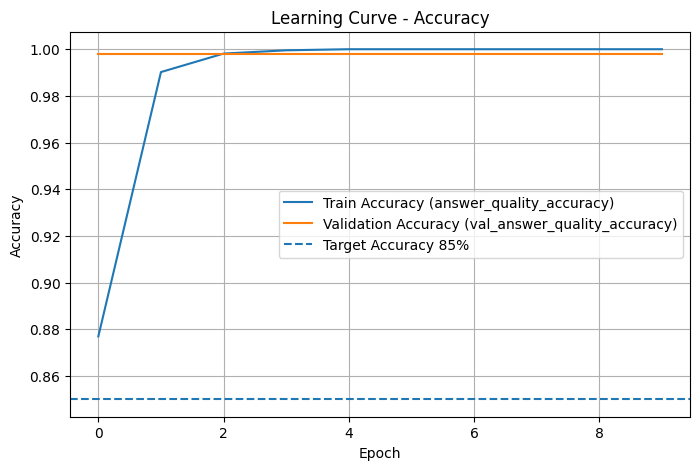

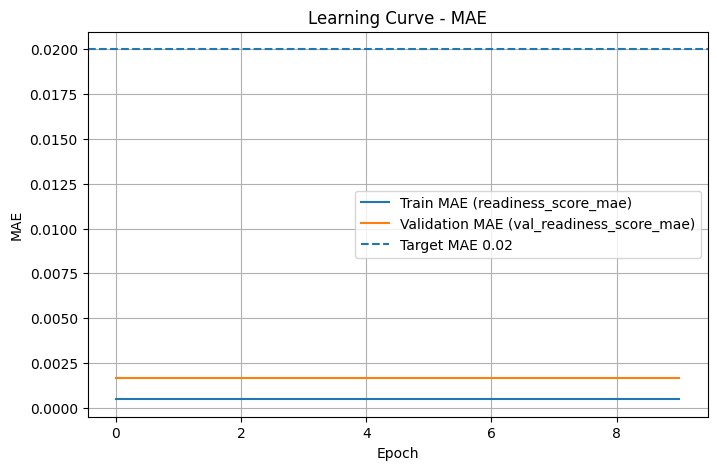

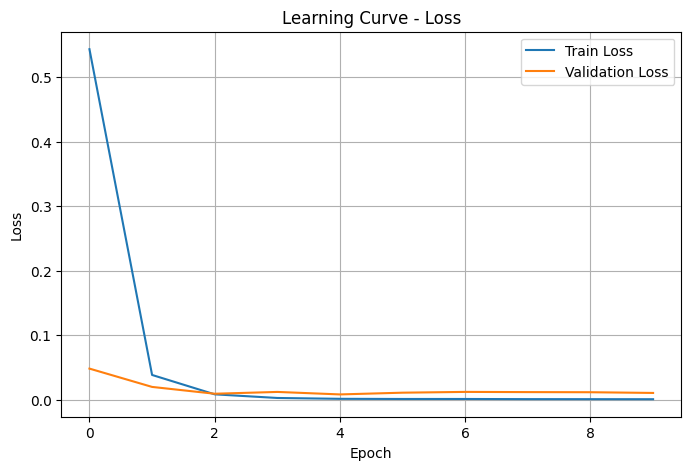

In [4]:
import json
import matplotlib.pyplot as plt
from model_builder import ANSWER_QUALITY_META_PATH

meta = json.loads(Path(ANSWER_QUALITY_META_PATH).read_text())
hist = meta.get("last_history", {})
print("Available history keys:")
for key in hist.keys():
    print("-", key)

def find_key(keyword, val=False, prefer=None):
    keys = [k for k in hist if (k.startswith("val_") if val else not k.startswith("val_")) and keyword.lower() in k.lower()]
    if prefer:
        pref = [k for k in keys if prefer.lower() in k.lower()]
        if pref:
            return pref[0]
    return keys[0] if keys else None

train_acc_key = find_key("accuracy", val=False, prefer="answer_quality")
val_acc_key = find_key("accuracy", val=True, prefer="answer_quality")
if train_acc_key and val_acc_key:
    plt.figure(figsize=(8,5))
    plt.plot(hist[train_acc_key], label=f"Train Accuracy ({train_acc_key})")
    plt.plot(hist[val_acc_key], label=f"Validation Accuracy ({val_acc_key})")
    plt.axhline(y=0.85, linestyle="--", label="Target Accuracy 85%")
    plt.title("Learning Curve - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

train_mae_key = find_key("mae", val=False, prefer="readiness_score")
val_mae_key = find_key("mae", val=True, prefer="readiness_score")
if train_mae_key and val_mae_key:
    plt.figure(figsize=(8,5))
    plt.plot(hist[train_mae_key], label=f"Train MAE ({train_mae_key})")
    plt.plot(hist[val_mae_key], label=f"Validation MAE ({val_mae_key})")
    plt.axhline(y=0.02, linestyle="--", label="Target MAE 0.02")
    plt.title("Learning Curve - MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

if "loss" in hist and "val_loss" in hist:
    plt.figure(figsize=(8,5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title("Learning Curve - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Evaluate train / validation / test
Test set adalah bukti final, bukan training accuracy.

In [5]:
report = evaluate_split_datasets(include_predictions=False)
for split, result in report.items():
    print(f"\n=== {split.upper()} ===")
    if "error" in result:
        print(result)
        continue
    print("Samples :", result["n_samples"])
    print(f"Accuracy: {result['answer_quality_accuracy']:.4f} | Target >= 0.85 |", "PASS" if result["target_accuracy_pass"] else "NOT PASS")
    print(f"MAE     : {result['readiness_score_mae']:.4f} | Target <= 0.02 |", "PASS" if result["target_mae_pass"] else "NOT PASS")
    print("Per-class accuracy:", result["per_class_accuracy"])
    print("Confusion matrix:", result["confusion_matrix_readable"])



=== TRAIN ===
Samples : 2145
Accuracy: 1.0000 | Target >= 0.85 | PASS
MAE     : 0.0021 | Target <= 0.02 | PASS
Per-class accuracy: {'Weak': 1.0, 'Average': 1.0, 'Strong': 1.0}
Confusion matrix: {'Weak': {'Weak': 715, 'Average': 0, 'Strong': 0}, 'Average': {'Weak': 0, 'Average': 715, 'Strong': 0}, 'Strong': {'Weak': 0, 'Average': 0, 'Strong': 715}}

=== VAL ===
Samples : 460
Accuracy: 0.9978 | Target >= 0.85 | PASS
MAE     : 0.0033 | Target <= 0.02 | PASS
Per-class accuracy: {'Weak': 0.9934640522875817, 'Average': 1.0, 'Strong': 1.0}
Confusion matrix: {'Weak': {'Weak': 152, 'Average': 1, 'Strong': 0}, 'Average': {'Weak': 0, 'Average': 153, 'Strong': 0}, 'Strong': {'Weak': 0, 'Average': 0, 'Strong': 154}}

=== TEST ===
Samples : 460
Accuracy: 0.9978 | Target >= 0.85 | PASS
MAE     : 0.0034 | Target <= 0.02 | PASS
Per-class accuracy: {'Weak': 1.0, 'Average': 0.9935064935064936, 'Strong': 1.0}
Confusion matrix: {'Weak': {'Weak': 153, 'Average': 0, 'Strong': 0}, 'Average': {'Weak': 0, 'Av

## Confusion matrix plot untuk test set

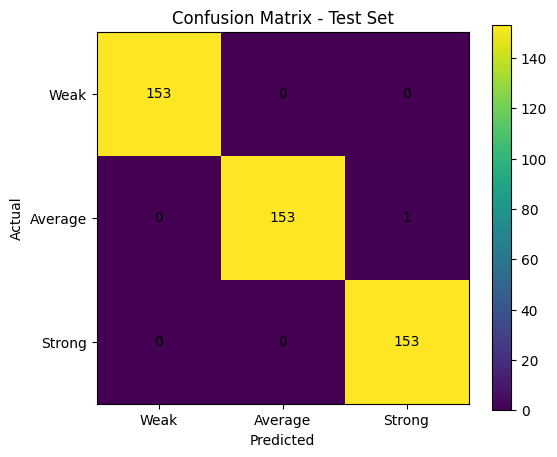

In [6]:
import numpy as np
test_report = report.get("test", {})
labels = test_report.get("labels", ["Weak", "Average", "Strong"])
cm = np.array(test_report.get("confusion_matrix", []))
if cm.size:
    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title("Confusion Matrix - Test Set")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.colorbar()
    plt.show()

## Inference test

In [7]:
predict_answer_quality(
    question="Ceritakan project AI yang pernah kamu buat.",
    answer="Saya membuat model klasifikasi teks menggunakan Python dan TensorFlow untuk project kampus. Saya bertanggung jawab membersihkan data, melatih model, dan mengevaluasi akurasi sampai 88%.",
    role="AI Engineer",
)

{'label': 'Strong',
 'confidence': 1.0,
 'supporting_readiness_score': 86,
 'supporting_score_0_1': 0.8579,
 'probabilities': {'Weak': 0.0, 'Average': 0.0, 'Strong': 1.0},
 'features': {'has_tool': 1,
  'has_metric': 1,
  'has_impact': 1,
  'has_action': 1,
  'has_context': 1,
  'evidence_level': 5,
  'evidence_level_norm': 1.0,
  'answer_length_words_norm': 0.096,
  'answer_length_words_estimate': 24,
  'role_relevance_feature': 0.9548,
  'star_structure_feature': 0.98,
  'evidence_specificity_feature': 1.0,
  'technical_accuracy_feature': 0.8096,
  'communication_clarity_feature': 0.5836,
  'self_awareness_feature': 0.45},
 'source': 'tensorflow_model'}

## Custom Training Loop dengan `tf.GradientTape`

Cell ini menjalankan training manual penuh tanpa `model.fit()`. Training step, validation step, metric tracking, TensorBoard logging, early stopping, dan export model dilakukan di dalam fungsi `train_answer_quality_model_custom_loop()`.

In [8]:
from ds_assets import answer_quality_train_path, answer_quality_val_path, answer_quality_test_path
from model_builder import train_answer_quality_model_custom_loop

custom_model = train_answer_quality_model_custom_loop(
    train_csv_path=str(answer_quality_train_path()),
    val_csv_path=str(answer_quality_val_path()),
    test_csv_path=str(answer_quality_test_path()),
    epochs=25,
    batch_size=32,
    learning_rate=1e-3,
    min_accuracy=0.85,
    max_mae=0.02,
)

custom_model is not None

[custom_loop] epoch=01 loss=0.3353 acc=0.8266 mae=0.0005 | val_loss=0.0194 val_acc=0.9978 val_mae=0.0016
🎯 [custom_loop] Target tercapai: val_accuracy=99.78%, val_MAE=0.0016.
[custom_loop] ✅ Model tersimpan: ./models/answer_quality_model.keras
[custom_loop] ✅ TensorBoard log dir: models\logs\gradient_tape\20260526-022934


True

## TensorBoard

Training via `model.fit()` sudah memakai `TensorBoard` callback. Custom `tf.GradientTape` loop juga menulis scalar secara manual menggunakan `tf.summary.scalar`. Jalankan cell ini untuk membuka TensorBoard di notebook.

In [9]:
%load_ext tensorboard
%tensorboard --logdir models/logs

Reusing TensorBoard on port 6006 (pid 25740), started 4:20:35 ago. (Use '!kill 25740' to kill it.)

## Cek Metadata Training Terakhir

Metadata ini menunjukkan apakah training terakhir memakai `model_fit` atau `custom_gradient_tape`, serta lokasi log TensorBoard.

In [10]:
import json
from pathlib import Path
from model_builder import ANSWER_QUALITY_META_PATH

meta = json.loads(Path(ANSWER_QUALITY_META_PATH).read_text(encoding="utf-8"))
print("training_method:", meta.get("training_method"))
print("tensorboard_log_dir:", meta.get("tensorboard_log_dir"))
print("train_dataset_path:", meta.get("train_dataset_path"))
print("val_dataset_path:", meta.get("val_dataset_path"))
print("test_dataset_path:", meta.get("test_dataset_path"))

training_method: custom_gradient_tape
tensorboard_log_dir: models\logs\gradient_tape\20260526-022934
train_dataset_path: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_train.csv
val_dataset_path: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_val.csv
test_dataset_path: D:\Kuliah\Semester 6\Capstone\Capstone Project\data_science_resources\dataset_test.csv
